### Setup

Installs everything this notebook needs into the current kernel. Safe to
re-run — `pip` skips anything already satisfied.


In [1]:
%pip install -q torch onnx onnxscript onnxruntime numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 7.7 MB/s eta 0:00:00


In [2]:
%pip install -q jupyter ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.4 MB/s eta 0:00:00


In [3]:
# Import all required packages
import torch
import onnx
import onnxscript
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt

# Print versions to confirm
print("✅ All packages imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"ONNX version: {onnx.__version__}")
print(f"ONNX Runtime version: {ort.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

# Quick test: create a simple tensor
x = torch.tensor([1.0, 2.0, 3.0])
print(f"\nTest tensor: {x}")
print("✅ Everything is working!")

✅ All packages imported successfully!
PyTorch version: 2.11.0+cpu
ONNX version: 1.22.0
ONNX Runtime version: 1.28.0
NumPy version: 2.0.2
Matplotlib version: 3.10.0

Test tensor: tensor([1., 2., 3.])
✅ Everything is working!


# From Neural Network to ONNX: a minimal end-to-end demo

We train a tiny MLP to learn `y = m*x + c` from noisy data, export it to
**ONNX**, and run inference with **ONNX Runtime** — first on a single
sample, then on a batch.

Agenda:
1. Synthetic data for `y = m*x + c`
2. A small MLP in PyTorch
3. Train it
4. Export to ONNX (`torch.onnx.export`)
5. Single-sample inference with ONNX Runtime
6. Batch inference + a timing comparison


In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import torch
import torch.nn as nn

torch.manual_seed(0)


## 1. The problem: recover `y = m*x + c` from noisy samples

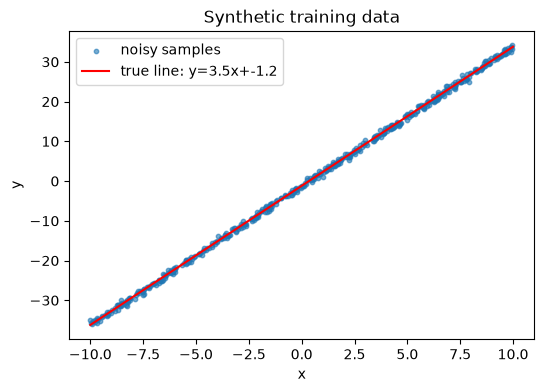

In [ ]:
TRUE_M = 3.5
TRUE_C = -1.2
NOISE_STD = 0.5


def generate_data(n_samples=500, m=TRUE_M, c=TRUE_C, noise_std=NOISE_STD, x_range=(-10, 10), seed=0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_range[0], x_range[1], size=(n_samples, 1)).astype(np.float32)
    noise = rng.normal(0, noise_std, size=(n_samples, 1)).astype(np.float32)
    y = (m * x + c + noise).astype(np.float32)
    return torch.from_numpy(x), torch.from_numpy(y)


x, y = generate_data()
n_train = int(0.8 * len(x))
x_train, y_train = x[:n_train], y[:n_train]
x_val, y_val = x[n_train:], y[n_train:]

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=10, alpha=0.6, label="noisy samples")
xs = np.linspace(-10, 10, 100)
plt.plot(xs, TRUE_M * xs + TRUE_C, color="red", label=f"true line: y={TRUE_M}x+{TRUE_C}")
plt.legend()
plt.title("Synthetic training data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 2. A small MLP

Even though the underlying relationship is linear, we use a two-hidden-layer
MLP with ReLU activations so the demo generalizes to the "real" NN → ONNX
workflow (the same steps work for any `nn.Module`).


In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=(16, 16)):
        super().__init__()
        sizes = [1, *hidden_sizes, 1]
        layers = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MLP()
model


MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

## 3. Train

In [ ]:
EPOCHS = 500
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

history = {"train": [], "val": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(x_train)
    loss = loss_fn(pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(x_val), y_val)

    history["train"].append(loss.item())
    history["val"].append(val_loss.item())

    if epoch % 100 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  train_loss={loss.item():.4f}  val_loss={val_loss.item():.4f}")

print(f"\nNoise variance floor to expect: {NOISE_STD**2:.4f}")


epoch    1  train_loss=417.3668  val_loss=315.6151
epoch  100  train_loss=0.4151  val_loss=0.4562
epoch  200  train_loss=0.2345  val_loss=0.2726
epoch  300  train_loss=0.2246  val_loss=0.2610
epoch  400  train_loss=0.2198  val_loss=0.2555


epoch  500  train_loss=0.2175  val_loss=0.2525

Noise variance floor to expect: 0.2500


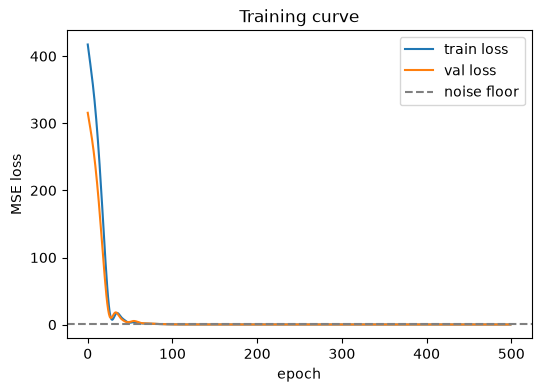

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["train"], label="train loss")
plt.plot(history["val"], label="val loss")
plt.axhline(NOISE_STD**2, color="gray", linestyle="--", label="noise floor")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.title("Training curve")
plt.show()


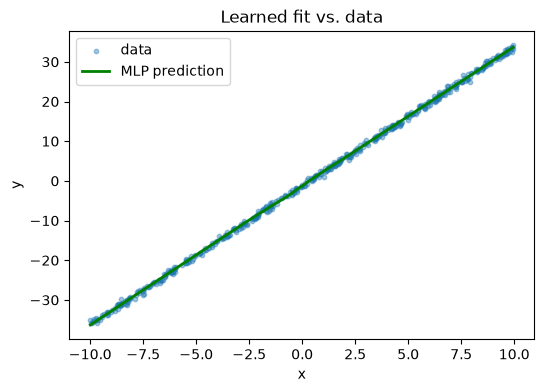

In [ ]:
model.eval()
with torch.no_grad():
    preds = model(x)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=10, alpha=0.4, label="data")
order = torch.argsort(x, dim=0).squeeze()
plt.plot(x[order].numpy(), preds[order].numpy(), color="green", linewidth=2, label="MLP prediction")
plt.legend()
plt.title("Learned fit vs. data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 4. Export to ONNX

`torch.onnx.export` traces the model and writes out a computation graph in
the ONNX format. We mark the batch dimension as dynamic (`dynamic_shapes`)
so the exported graph accepts any batch size at inference time, not just
the batch size used for tracing.


In [ ]:
import os

os.makedirs("models", exist_ok=True)
ONNX_PATH = "models/mlp.onnx"

dummy_input = torch.randn(1, 1)  # (batch=1, features=1)
batch_dim = torch.export.Dim("batch")

torch.onnx.export(
    model,
    (dummy_input,),
    ONNX_PATH,
    input_names=["x"],
    output_names=["y"],
    dynamic_shapes={"x": {0: batch_dim}},
    opset_version=18,
    external_data=False,
)
print(f"Exported to {ONNX_PATH}")


W0728 05:40:04.195000 3489341 site-packages/torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


W0728 05:40:04.196000 3489341 site-packages/torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align


W0728 05:40:04.196000 3489341 site-packages/torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool


W0728 05:40:04.196000 3489341 site-packages/torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::deform_conv2d


[torch.onnx] Obtain model graph for `MLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported to models/mlp.onnx


/home/sushant/anaconda3/envs/onnx_workshop/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


In [ ]:
onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid.\n")

for inp in onnx_model.graph.input:
    dims = [d.dim_param or d.dim_value for d in inp.type.tensor_type.shape.dim]
    print(f"input  '{inp.name}': shape={dims}")
for out in onnx_model.graph.output:
    dims = [d.dim_param or d.dim_value for d in out.type.tensor_type.shape.dim]
    print(f"output '{out.name}': shape={dims}")


ONNX model is valid.

input  'x': shape=['batch', 1]
output 'y': shape=['batch', 1]


## 5. Single-sample inference with ONNX Runtime

We load the `.onnx` file into an `InferenceSession` and run it on one input
at a time, comparing against the original PyTorch model to confirm the
export preserved the model's behavior.


In [ ]:
session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
print("ONNX Runtime input:", input_name, session.get_inputs()[0].shape)

x_single = np.array([[4.0]], dtype=np.float32)
onnx_out = session.run(None, {input_name: x_single})[0]

with torch.no_grad():
    torch_out = model(torch.from_numpy(x_single)).numpy()

print(f"input={x_single.flatten()}")
print(f"  torch prediction: {torch_out.flatten()}")
print(f"  onnx  prediction: {onnx_out.flatten()}")
np.testing.assert_allclose(torch_out, onnx_out, rtol=1e-4, atol=1e-4)
print("  match: OK")


ONNX Runtime input: x ['batch', 1]
input=[4.]
  torch prediction: [12.782359]
  onnx  prediction: [12.782361]
  match: OK


## 6. Batch inference

In [ ]:
batch_size = 8
x_batch = np.linspace(-10, 10, batch_size, dtype=np.float32).reshape(-1, 1)

onnx_batch_out = session.run(None, {input_name: x_batch})[0]
with torch.no_grad():
    torch_batch_out = model(torch.from_numpy(x_batch)).numpy()

print(f"batch input:  {x_batch.flatten()}")
print(f"torch preds:  {torch_batch_out.flatten()}")
print(f"onnx  preds:  {onnx_batch_out.flatten()}")
np.testing.assert_allclose(torch_batch_out, onnx_batch_out, rtol=1e-4, atol=1e-4)
print("match: OK")


batch input:  [-10.         -7.142857   -4.285714   -1.4285715   1.4285715   4.285714
   7.142857   10.       ]
torch preds:  [-36.323643  -26.227102  -16.130564   -6.249404    3.8251708  13.78513
  23.812824   33.84052  ]
onnx  preds:  [-36.323643  -26.227106  -16.130562   -6.2494035   3.8251708  13.78513
  23.812822   33.84052  ]
match: OK


### Single calls in a loop vs. one batched call

1000 single calls:  2.86 ms
1 batched call:   0.09 ms
speedup: 32.1x


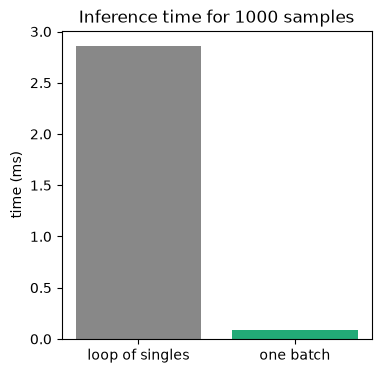

In [ ]:
n = 1000
x_many = np.random.uniform(-10, 10, size=(n, 1)).astype(np.float32)

start = time.perf_counter()
for i in range(n):
    session.run(None, {input_name: x_many[i : i + 1]})
loop_time = time.perf_counter() - start

start = time.perf_counter()
session.run(None, {input_name: x_many})
batch_time = time.perf_counter() - start

print(f"{n} single calls:  {loop_time * 1000:.2f} ms")
print(f"1 batched call:   {batch_time * 1000:.2f} ms")
print(f"speedup: {loop_time / batch_time:.1f}x")

plt.figure(figsize=(4, 4))
plt.bar(["loop of singles", "one batch"], [loop_time * 1000, batch_time * 1000], color=["#888", "#2a7"])
plt.ylabel("time (ms)")
plt.title(f"Inference time for {n} samples")
plt.show()


## Takeaways

- The exported ONNX graph is a static computation graph — no Python, no
  PyTorch runtime needed to run it.
- Marking the batch axis dynamic at export time lets the same `.onnx` file
  serve single-sample and batched requests.
- Batching is *much* cheaper than looping over singles: fewer Python/runtime
  round-trips and better use of vectorized ops.
